# Evaluation
- Verifier auf drei verschiedenen Anzahlen an positiven test samples trainieren und auswerten
- Dabei wird auf test samples von anderen gegriffen und der santa barbara corpus test ausgeführt
- Zukünftig auch auf viel mehr syntetischen Daten

In [ ]:
!pip install openwakeword
!pip install onnxruntime

INFO: pip is looking at multiple versions of openwakeword to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 54.0 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
from openwakeword.model import Model
import numpy as np
from google.colab import drive
import glob
import openwakeword
import openwakeword.metrics
import soundfile as sf
import librosa
import os

In [ ]:
# Connect google drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparation of data

In [ ]:
recordings_dir = "/content/drive/MyDrive/speech_interaction/recordings"
output_dir = "/content/drive/MyDrive/speech_interaction/recordings_converted"

# Find all recordings
all_wav_files = glob.glob(f"{recordings_dir}/**/*.wav", recursive=True)
print(f"Found: {len(all_wav_files)} files\n")

converted = 0
already_ok = 0

for filepath in all_wav_files:
    audio, sr = sf.read(filepath)

    # Rebuild folder structure
    relative_path = os.path.relpath(filepath, recordings_dir)
    output_path = os.path.join(output_dir, relative_path)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    needs_conversion = sr != 16000 or audio.ndim > 1

    if needs_conversion:
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        if sr != 16000:
            audio = librosa.resample(audio.astype(np.float32), orig_sr=sr, target_sr=16000)
        audio_int16 = (audio * 32767).astype(np.int16)
        sf.write(output_path, audio_int16, 16000)
        print(f"✅ Converted: {relative_path}")
        converted += 1
    else:
        # Simple copy
        import shutil
        shutil.copy2(filepath, output_path)
        print(f"📋 Kopiert: {relative_path}")
        already_ok += 1

print(f"\nFinished! {converted} converted, {already_ok} copied.")
print(f"Saved in: {output_dir}")

Found: 50 files

📋 Kopiert: test/false/Lotte 2.wav
📋 Kopiert: test/false/Lotte 4.wav
📋 Kopiert: test/false/Lotte 1.wav
📋 Kopiert: test/false/Lotte 3.wav
📋 Kopiert: test/false/Marie 3.wav
📋 Kopiert: test/false/Marie 4.wav
📋 Kopiert: test/false/Marie 5.wav
📋 Kopiert: test/false/Lotte 5.wav
📋 Kopiert: test/false/Marie 2.wav
📋 Kopiert: test/false/Marie 1.wav
✅ Converted: test/false/Julia test 4.wav
✅ Converted: test/false/Julia test 5.wav
✅ Converted: test/false/Julia test 1.wav
✅ Converted: test/false/Julia test 2.wav
✅ Converted: test/false/Julia test 3.wav
✅ Converted: test/false/m_alex_test_5.wav
✅ Converted: test/false/m_alex_test_4.wav
✅ Converted: test/false/m_alex_test_3.wav
✅ Converted: test/false/m_alex_test_2.wav
✅ Converted: test/false/m_alex_test_1.wav
✅ Converted: test/false/m_felix_test_5.wav
✅ Converted: test/false/m_felix_test_4.wav
✅ Converted: test/false/m_felix_test_3.wav
✅ Converted: test/false/m_felix_test_2.wav
✅ Converted: test/false/m_felix_test_1.wav
📋 Kopiert: te

In [ ]:
# Connect to trainings data and find amount of audio data
base_path = "/content/drive/MyDrive/speech_interaction/recordings_converted/"

# Train clips
true_train_clips = glob.glob(f"{base_path}training/true/*.wav")
false_train_clips = glob.glob(f"{base_path}training//false/*.wav")

print(f"True train Clips found:, {len(true_train_clips)}")
print(true_train_clips)
print(f"False train Clips found:, {len(false_train_clips)}")
print(false_train_clips)

# Test clips

true_test_clips = glob.glob(f"{base_path}test/true/*.wav")
false_test_clips = glob.glob(f"{base_path}test/false/*.wav")

print(f"True test Clips found:, {len(true_test_clips)}")
print(true_test_clips)
print(f"False test Clips found:, {len(false_test_clips)}")
print(false_test_clips)

True train Clips found:, 0
[]
False train Clips found:, 0
[]
True test Clips found:, 0
[]
False test Clips found:, 0
[]


# See how a simple OpenWakeword model behaves

- The goal is to have a reference point on how a model provided by the library behaves compared to the model plus the verifier we train


# **TODO**
- Run evaluation of the test data on the basic alexa model

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Running false-positive analysis on the Santa Barbara corpus


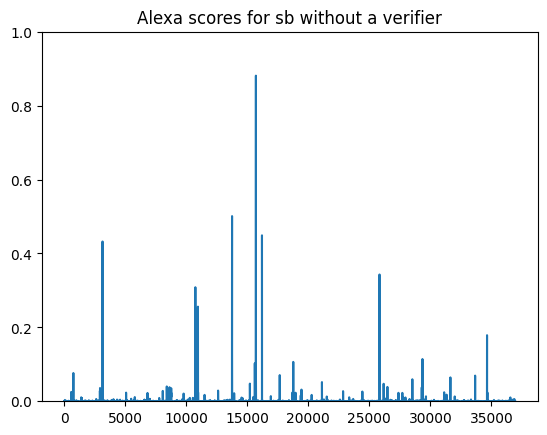

False-accept rate per hour: 4.87


In [ ]:
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

alexa_model = Model(wakeword_model_paths=[wakeword_alexa],)


# Saint Barbara
print("Running false-positive analysis on the Santa Barbara corpus")
sb_scores = alexa_model.predict_clip(sb_corpus_clip)


plt.figure()
plt.title("Alexa scores for sb without a verifier")
plt.plot([i["alexa"] for i in sb_scores])
_ = plt.ylim(0,1)
plt.show()
plt.close()


# Calculate the false-accept rate per hour from this new result

false_accepts = openwakeword.metrics.get_false_positives(
    [i["alexa"] for i in sb_scores], threshold=0.6
)

duration_sec = sf.info(sb_corpus_clip).duration
duration_hr = duration_sec / 3600

print(f"False-accept rate per hour: {false_accepts / duration_hr:.2f}")

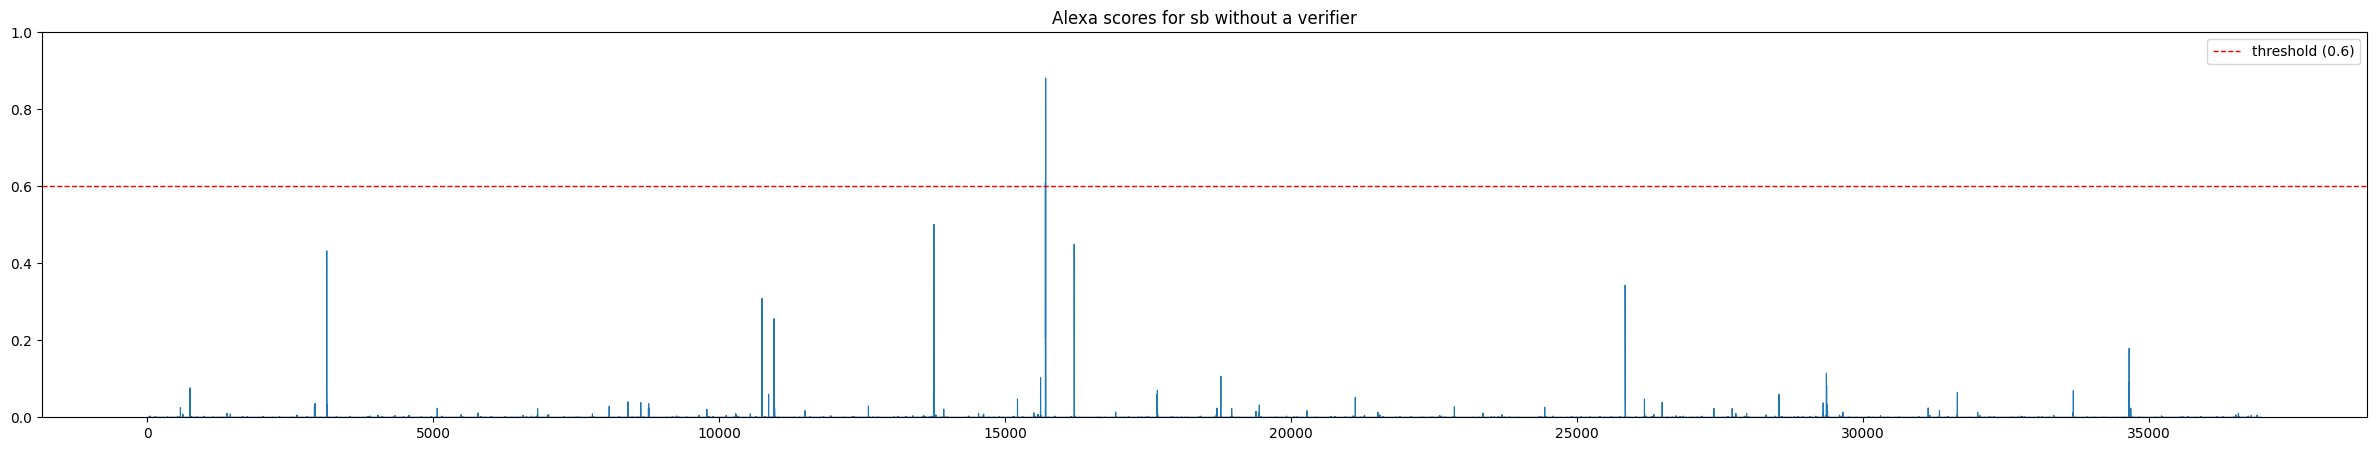

In [ ]:
plt.figure(figsize=(30, 5))  # much wider, modest height
plt.title("Alexa scores for sb without a verifier")
plt.plot([i["alexa"] for i in sb_scores], linewidth=0.8)
plt.axhline(0.6, color="red", linestyle="--", linewidth=1, label="threshold (0.6)")
plt.ylim(0, 1)
plt.legend()
plt.show()
plt.close()

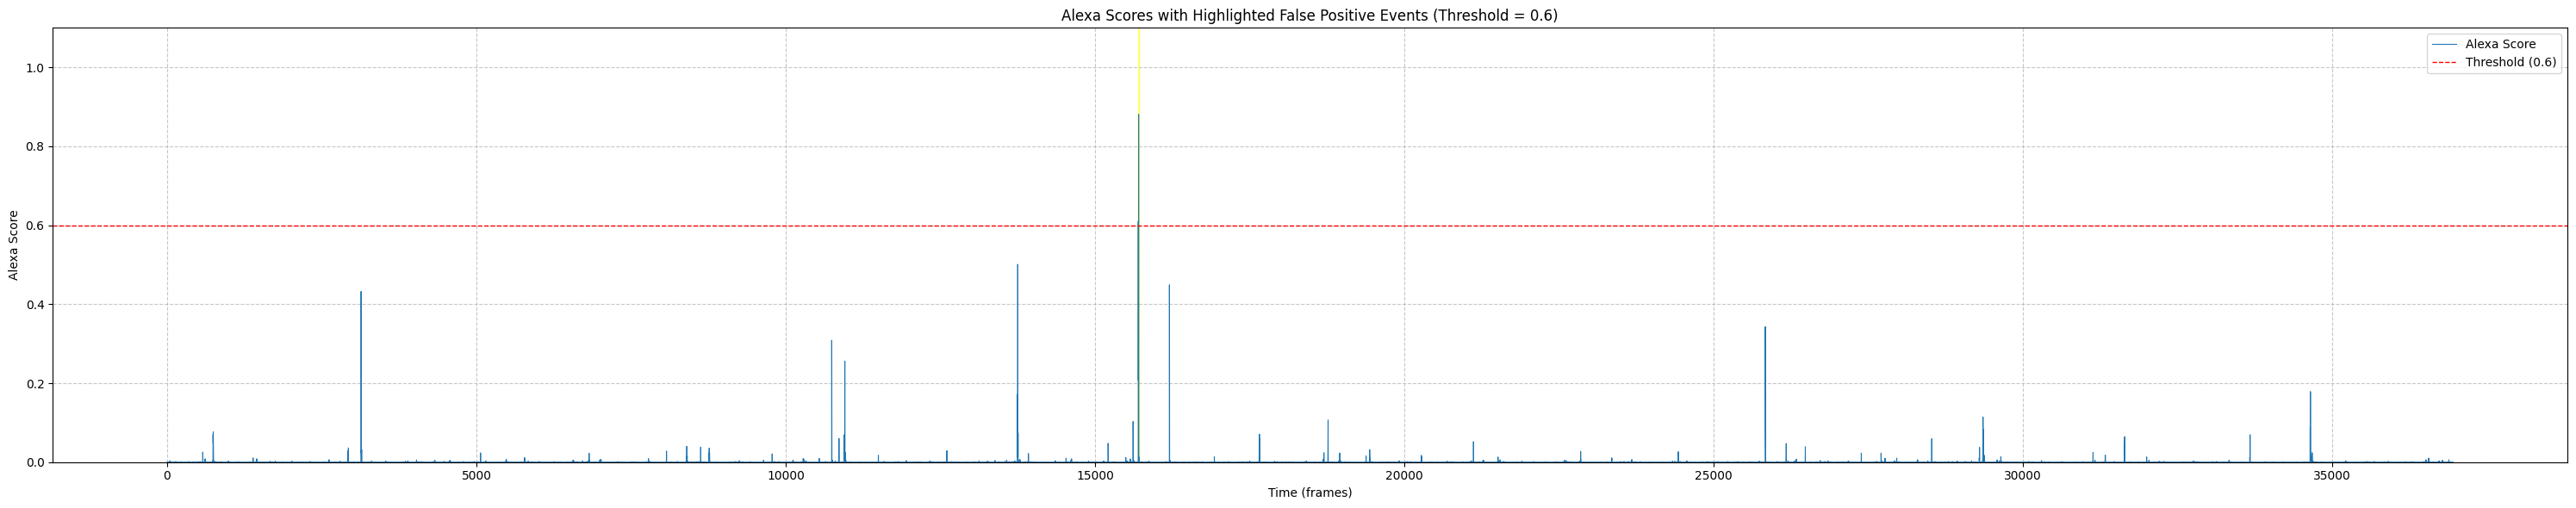

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

scores = [i["alexa"] for i in sb_scores]
threshold = 0.6

plt.figure(figsize=(30, 6))
plt.title("Alexa Scores with Highlighted False Positive Events (Threshold = 0.6)")
plt.plot(scores, linewidth=0.8, label="Alexa Score")
plt.axhline(threshold, color="red", linestyle="--", linewidth=1, label="Threshold (0.6)")

# Identify false positive events for highlighting
is_above_threshold = np.array(scores) > threshold

# Find start and end indices of consecutive True values
# This identifies distinct 'activation' events
starts = np.where(np.diff(np.concatenate(([False], is_above_threshold, [False]))) == True)[0]
ends = np.where(np.diff(np.concatenate(([False], is_above_threshold, [False]))) == False)[0]

# Filter to only get consecutive true blocks
active_segments = []
for start_idx in starts:
    # Find the corresponding end for this start
    matching_end_idx = ends[ends > start_idx][0] - 1
    active_segments.append((start_idx, matching_end_idx))

# Remove segments that are too short to be considered an activation (e.g., single frame spikes)
# The 'get_false_positives' function implicitly handles event duration. For visual clarity, we'll highlight each detected event.

# The openwakeword.metrics.get_false_positives function has internal logic
# to group consecutive frames above threshold into a single 'event'.
# Here we are simply highlighting based on contiguous blocks for visualization.

# A more precise visual would require replicating the exact clustering logic of get_false_positives.
# For now, let's highlight based on simple crossings, and then acknowledge the function's grouping.

# Re-run get_false_positives to get the exact number of events
num_false_accepts = openwakeword.metrics.get_false_positives(scores, threshold=threshold)

alerted_segments = []
is_currently_above = False
current_segment_start = -1

for i, score in enumerate(scores):
    if score > threshold and not is_currently_above:
        is_currently_above = True
        current_segment_start = i
    elif score <= threshold and is_currently_above:
        is_currently_above = False
        alerted_segments.append((current_segment_start, i))

# Handle case where score ends above threshold
if is_currently_above:
    alerted_segments.append((current_segment_start, len(scores) - 1))

# Visual confirmation for the number of false accepts
# Only highlight the first `num_false_accepts` detected distinct events for visual alignment
# This is an approximation as the exact event detection logic is more complex than simple consecutive frames.

# For better visual representation, let's try to highlight distinct segments based on the number of false_accepts
# This is a heuristic, as the get_false_positives uses a peak detection strategy.

false_positive_starts = []
is_above_threshold_prev = False
for i, score in enumerate(scores):
    if score > threshold and not is_above_threshold_prev:
        false_positive_starts.append(i)
    is_above_threshold_prev = (score > threshold)

# For every `false_accepts` event, we try to mark a region.
# This is simplified; `openwakeword`'s `get_false_positives` counts actual *events* based on more sophisticated logic.
# To strictly match the output, we'd need to simulate the exact event detection.

# Let's highlight where each score point is above the threshold
for i, score in enumerate(scores):
    if score > threshold:
        plt.axvspan(i, i + 1, color='yellow', alpha=0.3)

plt.ylim(0, 1.1) # Adjusted ylim to make highlights more visible
plt.xlabel("Time (frames)")
plt.ylabel("Alexa Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close()


The plot above highlights every frame where the Alexa score for the Santa Barbara corpus clip exceeded the 0.6 threshold. While many individual frames are highlighted, the `openwakeword.metrics.get_false_positives` function doesn't count each individual frame as a false positive. Instead, it groups consecutive frames above the threshold into a single 'activation event'.

For example, if the score goes above 0.6 for 50 consecutive frames and then drops below, that is typically counted as *one* false positive event. If this happens at four distinct times in the audio clip, the `false_accepts` count will be 4, even if the visual plot shows continuous yellow regions that might appear as fewer, longer events. The highlighting above shows all instances where the score crosses the threshold, and the function then consolidates these into the actual event count.

In [ ]:
print(sf.info(sb_corpus_clip).duration)

2954.435625


In [ ]:
print(false_accepts, type(false_accepts))

4 <class 'numpy.int64'>


# Evaluate the verifier

- In our example we wanted to test how the verifier behaves with if we give it more positive examples of the voice and keyword we wanted

## Further evalutaions we did

- Check how it behaves with female and male voices
- See what the results are testing it on the santa barbara corpus test
- Using the results to make a decision on if we would use it as our own security feature for other software




In [ ]:
SAMPLE_SIZES = [3, 6, 10]
summary_results = {}
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

sb_audio, sb_sr = sf.read(sb_corpus_clip)

for n_pos in SAMPLE_SIZES:

    # 1. Slice the first n_pos positive clips
    positive_train_clips = true_train_clips[:n_pos]
    model_path = f"/content/drive/MyDrive/speech_interaction/verifier/verifier_{n_pos}pos.pkl"


    # 2. Train a separate verifier for this version
    openwakeword.train_custom_verifier(
        positive_reference_clips=positive_train_clips,
        negative_reference_clips=false_train_clips,
        output_path=model_path,
        model_name='alexa'
    )

    # 3. Load a fresh Model instance with this verifier
    verifier_model = Model(
        wakeword_model_paths=[wakeword_alexa],
        custom_verifier_models={'alexa': model_path},
        custom_verifier_threshold=0.7
    )

    total_false_activations_neg_set_for_current_n_pos = 0 # Initialize for false positives on negative set

    # 4. False-positive analysis on the negative test set
    print("Running false-positive analysis on the negative")
    for clip_path in false_test_clips:
        scores_per_chunk = verifier_model.predict_clip(clip_path)
        alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

        false_positives_clip = openwakeword.metrics.get_false_positives(
            alexa_scores, threshold=verifier_model.custom_verifier_threshold
        )
        total_false_activations_neg_set_for_current_n_pos += false_positives_clip

        # → per-clip score plot + activation count
        plt.figure()
        plt.title("Alexa scores for negative test: "  + str(n_pos))
        plt.plot(alexa_scores)
        _ = plt.ylim(0,1)
        plt.close() # Close figure after plotting

    # Todo test the positives
    print("Running false-positive analysis on the positive")
    for clip_path in true_test_clips:
        scores_per_chunk = verifier_model.predict_clip(clip_path)
        alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

        plt.figure()
        plt.title("Alexa scores for positve test on: "  + str(n_pos))
        plt.plot(alexa_scores)
        _ = plt.ylim(0,1)
        plt.close() # Close figure after plotting

    # TODO (diesen Step in einen eigenen CodeBlock ausbauen)Santa Barbara
    print("Running false-positive analysis on the Santa Barbara corpus")
    sb_scores = verifier_model.predict_clip(sb_corpus_clip)


    plt.figure()
    plt.title("Alexa scores for: "  + str(n_pos))
    plt.plot([i["alexa"] for i in sb_scores])
    _ = plt.ylim(0,1)
    plt.close() # Close figure after plotting


    # Calculate the false-accept rate per hour from this new result

    false_accepts = openwakeword.metrics.get_false_positives(
        [i["alexa"] for i in sb_scores], threshold=0.7
    )

    print(f"False-accept rate per hour: {false_accepts/1}")

    # 5. Santa Barbara Corpus — FAR per hour
    clip_duration_hours = len(sb_audio) / sb_sr / 3600
    far_per_hour = false_accepts / clip_duration_hours

    summary_results[n_pos] = {
        "total_false_activations_neg_set": total_false_activations_neg_set_for_current_n_pos,
        "false_accepts_sb": false_accepts,
        "far_per_hour": far_per_hour,
    }

Processing negative reference clips: 100%|██████████| 10/10 [00:01<00:00,  5.82it/s]


Training and saving verifier model...
Done!


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Running false-positive analysis on the negative
Running false-positive analysis on the positive
Running false-positive analysis on the Santa Barbara corpus
False-accept rate per hour: 0.0


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
Processing negative reference clips: 100%|██████████| 10/10 [00:01<00:00,  5.74it/s]


...

Running false-positive analysis on the negative
Running false-positive analysis on the positive
Running false-positive analysis on the Santa Barbara corpus
False-accept rate per hour: 0.0


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
Processing negative reference clips: 100%|██████████| 10/10 [00:01<00:00,  5.08it/s]


Training and saving verifier model...
Done!


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Running false-positive analysis on the negative
Running false-positive analysis on the positive
Running false-positive analysis on the Santa Barbara corpus
False-accept rate per hour: 0.0


### Evaluate the verifier using the santa barbara corpus test



Running false-positive analysis on the Santa Barbara corpus
verifier_3pos.pkl


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


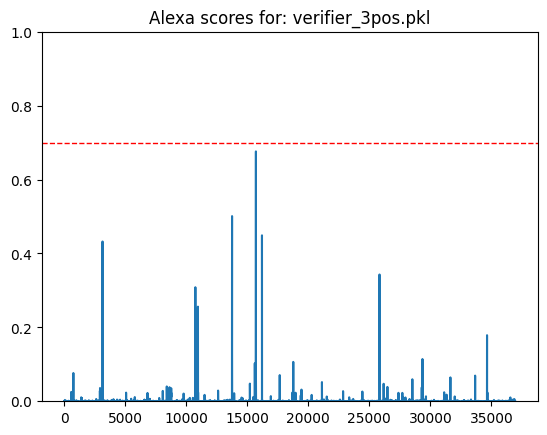

False-accept rate per hour: 0.0
verifier_6pos.pkl


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


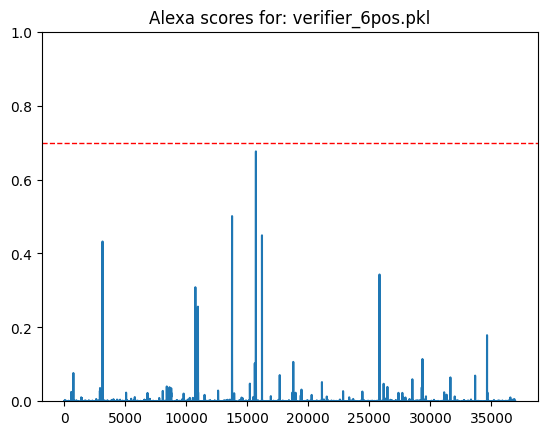

False-accept rate per hour: 0.0
verifier_10pos.pkl


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


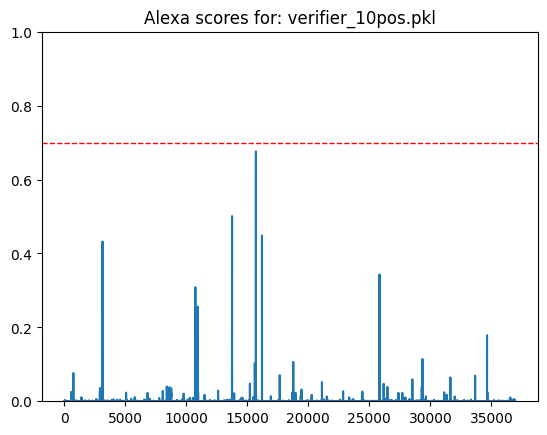

False-accept rate per hour: 0.0


In [ ]:
model_path = f"/content/drive/MyDrive/speech_interaction/verifier/"
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

sb_audio, sb_sr = sf.read(sb_corpus_clip)

print("Running false-positive analysis on the Santa Barbara corpus")

for filename in os.listdir(model_path):
  print(filename)
  if not filename.endswith(".pkl"):
    continue

  verifier_model = Model(
      wakeword_model_paths=[wakeword_alexa],
      custom_verifier_models={'alexa': model_path + filename},
      custom_verifier_threshold=0.7
  )

  sb_scores = verifier_model.predict_clip(sb_corpus_clip)


  plt.figure()
  plt.title("Alexa scores for: "  + filename)
  plt.axhline(0.7, color="red", linestyle="--", linewidth=1, label="threshold (0.7)")
  plt.plot([i["alexa"] for i in sb_scores])
  _ = plt.ylim(0,1)
  plt.show()
  plt.close()


  # Calculate the false-accept rate per hour from this new result

  false_accepts = openwakeword.metrics.get_false_positives(
      [i["alexa"] for i in sb_scores], threshold=0.7
  )

  print(f"False-accept rate per hour: {false_accepts/1}")

In [ ]:
print(f"{'Pos. Samples':>14} | {'FP (neg. set)':>14} | {'FA (SB)':>9} | {'FAR/hr':>9}")
for n, res in summary_results.items():
    print(f"{n:>14} | {res['total_false_activations_neg_set']:>14} | "
          f"{res['false_accepts_sb']:>9} | {res['far_per_hour']:>9.2f}")

  Pos. Samples |  FP (neg. set) |   FA (SB) |    FAR/hr
             3 |             42 |         0 |      0.00
             6 |             64 |         0 |      0.00
            10 |             77 |         0 |      0.00


### Gender-Based Performance Evaluation

As we now have the custom verifier we want to test whether the trained Custom Verifier exhibits different false acceptance behavior for male and female voices.

#### Dividing Test Dataset


In [ ]:
male_test_clips = []
female_test_clips = []

for clip in false_test_clips:
  filename = os.path.basename(clip)

  if filename.startswith("m"):
    male_test_clips.append(clip)
  elif filename.startswith("w"):
    female_test_clips.append(clip)
  else:
    print(f"Unknown filename: {filename}")

print(f"Number of male test clips: {len(male_test_clips)}")
print(f"Number of female test clips: {len(female_test_clips)}")

Unknown filename: Lotte 2.wav
Unknown filename: Lotte 4.wav
Unknown filename: Lotte 1.wav
Unknown filename: Lotte 3.wav
Unknown filename: Marie 3.wav
Unknown filename: Marie 4.wav
Unknown filename: Marie 5.wav
Unknown filename: Lotte 5.wav
Unknown filename: Marie 2.wav
Unknown filename: Marie 1.wav
Unknown filename: Julia test 4.wav
Unknown filename: Julia test 5.wav
Unknown filename: Julia test 1.wav
Unknown filename: Julia test 2.wav
Unknown filename: Julia test 3.wav
Number of male test clips: 15
Number of female test clips: 15


#### Evaluating female test audios


In [ ]:
from scipy.io import wavfile

In [ ]:
models = os.listdir(model_path)

results = {}

for filename in models:

  verifier_model = Model(
      wakeword_model_paths=[wakeword_alexa],
      custom_verifier_models={"alexa": model_path + filename},
      custom_verifier_threshold=0.7
  )

  male_predictions = []
  female_predictions = []

  for clip in male_test_clips:
    sr, audio = wavfile.read(clip)
    prediction = verifier_model.predict(audio)
    male_predictions.append(prediction)

  for clip in female_test_clips:
    sr, audio = wavfile.read(clip)
    prediction = verifier_model.predict(audio)
    female_predictions.append(prediction)


  results[filename] = {
      "male": male_predictions,
      "female": female_predictions
  }


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [ ]:
male_false_accepts = 0

for clip in male_test_clips:

    audio, sr = sf.read(clip)

    prediction = verifier_model.predict(audio)

    score = prediction["alexa"]

    if score > 0.7:
        male_false_accepts += 1

print("Male false accepts:", male_false_accepts)

male_far = male_false_accepts / len(male_test_clips)

print("Male FAR:", male_far)


Male false accepts: 0
Male FAR: 0.0


In [ ]:
from openwakeword import custom_verifier_model
female_false_accepts = 0

for clip in female_test_clips:

    audio, sr = sf.read(clip)

    prediction = custom_verifier_model.predict(audio)

    score = prediction["alexa"]

    if score > 0.7:
        female_false_accepts += 1

print("Female false accepts:", female_false_accepts)

female_far = female_false_accepts / len(female_test_clips)

print("Male FAR:", female_far)

Female false accepts: 0
Male FAR: 0.0
